In [44]:
!pip install ydata-profiling pandas


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [45]:
import pandas as pd
from ydata_profiling import ProfileReport
import os

# 1. Đường dẫn thư mục của bạn
folder_path = r'D:\the_look_portfilio\data_sample1'

# 2. Danh sách file CSV cần làm báo cáo
file_names = ['inventory_items.csv', 'order_items.csv', 'orders.csv', 'products.csv', 'users.csv']

# 3. Biến chứa nội dung HTML tổng hợp
full_html = "<html><body><h1 style='text-align:center;'>Báo cáo EDA Tổng hợp - The Look Portfolio</h1>"

for file in file_names:
    print(f"Đang xử lý file: {file}...")
    
    # Đọc dữ liệu (kết hợp đường dẫn thư mục và tên file)
    du_lieu = pd.read_csv(os.path.join(folder_path, file))
    
    # Tạo báo cáo nhanh (minimal=True)
    report = ProfileReport(du_lieu, title=file, minimal=True)
    
    # Cộng dồn nội dung vào file tổng
    full_html += f"<hr><h2>Bảng: {file}</h2>"
    full_html += report.to_html()

full_html += "</body></html>"

# 4. LƯU VÀO ĐÚNG THƯ MỤC folder_path
output_path = os.path.join(folder_path, "Bao_cao_EDA_Tong_Hop.html")

with open(output_path, "w", encoding="utf-8") as f:
    f.write(full_html)

print(f"\n--- THÀNH CÔNG! ---")
print(f"File đã được lưu tại: {output_path}")


Đang xử lý file: inventory_items.csv...


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:00<00:00, 18.59it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

...

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 16/16 [00:00<00:00, 82.78it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]


--- THÀNH CÔNG! ---
File đã được lưu tại: D:\the_look_portfilio\data_sample1\Bao_cao_EDA_Tong_Hop.html


### Load dataset

In [46]:

from pathlib import Path

folder = Path(r"D:/the_look_portfilio/data_sample1/")
data = {}

for file in folder.glob("*.csv"):
    data[file.stem] = pd.read_csv(file)

print(data.keys())

dict_keys(['inventory_items', 'orders', 'order_items', 'products', 'users'])


### Check shape

In [47]:
for name, df in data.items():
    print(name, df.shape)

inventory_items (50000, 12)
orders (18736, 9)
order_items (27354, 11)
products (17679, 9)
users (15000, 16)


### Check missing, duplicated values

In [48]:
dq_results = []

for name, df in data.items():

    rows = df.shape[0]
    cols = df.shape[1]

    missing = df.isna().sum().sum()
    duplicate = df.duplicated().sum()

    dq_results.append({
        "table": name,
        "rows": rows,
        "columns": cols,
        "missing_values": missing,
        "duplicates": duplicate
    })

dq_report = pd.DataFrame(dq_results)

print("\nData Quality Summary")
print(dq_report)


Data Quality Summary
             table   rows  columns  missing_values  duplicates
0  inventory_items  50000       12           31548           0
1           orders  18736        9           35753           0
2      order_items  27354       11           52299           0
3         products  17679        9              16           0
4            users  15000       16             140           0


In [70]:
for name, df in data.items():

    
    print(f"TABLE: {name}")
    print("-"*50)

    missing = pd.DataFrame({
        "missing_count": df.isnull().sum(),
        "missing_percent": round(df.isnull().mean() * 100, 2)
    })

    # chỉ hiển thị cột có missing
    missing = missing[missing["missing_count"] > 0]

    if missing.empty:
        print("No missing values\n")
    else:
        print(missing.sort_values("missing_percent", ascending=False))
        print("\n")

TABLE: inventory_items
--------------------------------------------------
         missing_count  missing_percent
sold_at          31512            63.02


TABLE: orders
--------------------------------------------------
              missing_count  missing_percent
returned_at           16836            89.86
delivered_at          12219            65.22
shipped_at             6698            35.75


TABLE: order_items
--------------------------------------------------
              missing_count  missing_percent
returned_at           24568            89.82
delivered_at          17828            65.18
shipped_at             9903            36.20


TABLE: products
--------------------------------------------------
No missing values

TABLE: users
--------------------------------------------------
No missing values



* sold_at missing values nhiều: hàng còn trong kho
* brand, name products city thiếu chưa tới 1% , không ảnh hưởng lớn tới quá trình phân tích


### Drop những cột không cần thiết

* products: sku, distribution_center_id
* users: 'first_name', 'last_name', 'email', 'street_address', 'postal_code', 'latitude', 'longitude', 'user_geom'
* enventory_items:, product_name, product_brand, product_retail_price, product_department, product_sku

In [57]:
cols_to_drop_users = [
    'first_name', 'last_name', 'email', 'street_address', 
    'postal_code', 'latitude', 'longitude', 'user_geom']
data['users']=data['users'].drop(columns=cols_to_drop_users, errors='ignore')

In [58]:
cols_to_drop_products = ['sku', 'distribution_center_id']
data['products']=data['products'].drop(columns=cols_to_drop_products, errors='ignore')

In [59]:
cols_to_drop_enventory_items=['product_name', 'product_brand', 'product_retail_price', 'product_department', 'product_sku']
data['inventory_items']=data['inventory_items'].drop(columns=cols_to_drop_enventory_items, errors='ignore')

In [60]:
def fill_unknown(df, cols):
    for col in cols:
        if col in df.columns:
            df[col] = df[col].fillna("Unknown")
    return df

In [69]:
for name, df in data.items():
    data[name] = fill_unknown(df, ["city","product_brand","name"])

### Check data type 

In [62]:
for name, df in data.items():
    print(f"{name}")
    df.info()
    print("-"*50)

inventory_items
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              50000 non-null  int64         
 1   product_id                      50000 non-null  category      
 2   created_at                      50000 non-null  datetime64[ns]
 3   sold_at                         18488 non-null  datetime64[ns]
 4   cost                            50000 non-null  float64       
 5   product_category                50000 non-null  object        
 6   product_distribution_center_id  50000 non-null  category      
dtypes: category(2), datetime64[ns](2), float64(1), int64(1), object(1)
memory usage: 2.1+ MB
--------------------------------------------------
orders
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18736 entries, 0 to 18735
Data columns (total 9 columns):
 #  

In [63]:
for name, df in data.items():
    
    for col in df.columns:
        if col.endswith("id"):
            df[col] = df[col].astype("category")

    print(f"{name} converted")

inventory_items converted
orders converted
order_items converted
products converted
users converted


In [64]:
for name, df in data.items():
    
    for col in df.columns:
        if col.endswith("_at"):
            df[col] = (
                pd.to_datetime(df[col], format="mixed", errors="coerce")
                .dt.tz_localize(None)
            )

    print(f"{name}: date columns converted")

inventory_items: date columns converted
orders: date columns converted
order_items: date columns converted
products: date columns converted
users: date columns converted


### Check outliers

In [67]:

outlier_summary = []

for name, df in data.items():
    numeric_cols = df.select_dtypes(include=["int64","float64"]).columns
    for col in numeric_cols:

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower) | (df[col] > upper)]
        if len(outliers)>0:
            outlier_summary.append({
            "table": name,
            "column": col,
            "outlier_count": len(outliers),
            "total_rows": len(df),
            "outlier_rate_%": round(len(outliers)/len(df)*100,2)
        })

outlier_report = pd.DataFrame(outlier_summary)

print(outlier_report)

             table        column  outlier_count  total_rows  outlier_rate_%
0  inventory_items          cost           3547       50000            7.09
1           orders   num_of_item            966       18736            5.16
2      order_items    sale_price           2362       27354            8.63
3         products          cost           1356       17679            7.67
4         products  retail_price           1532       17679            8.67


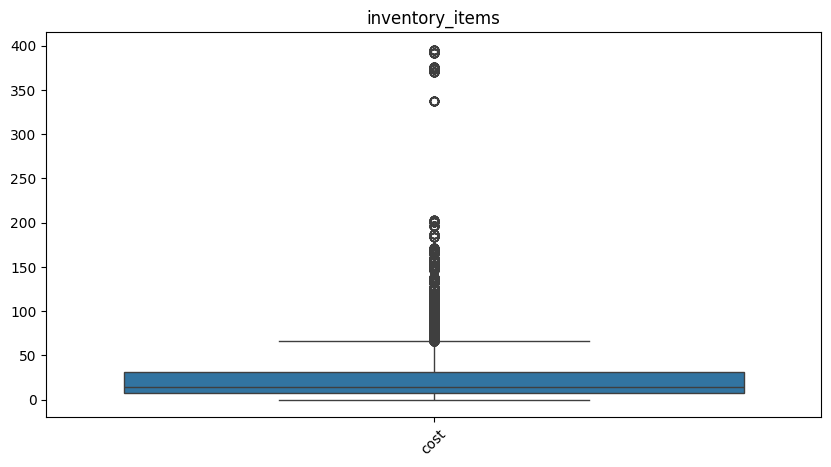

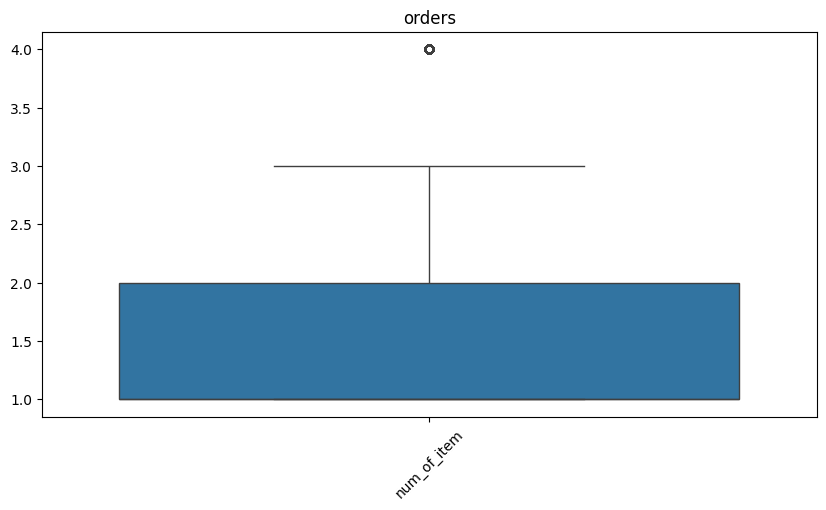

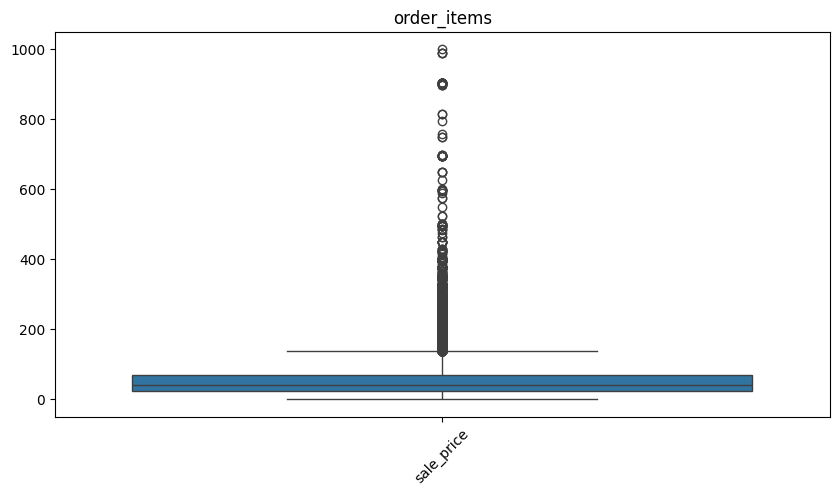

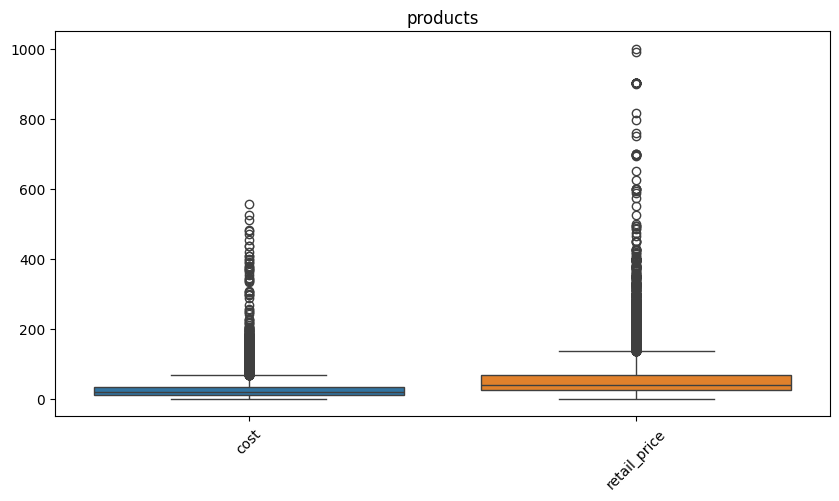

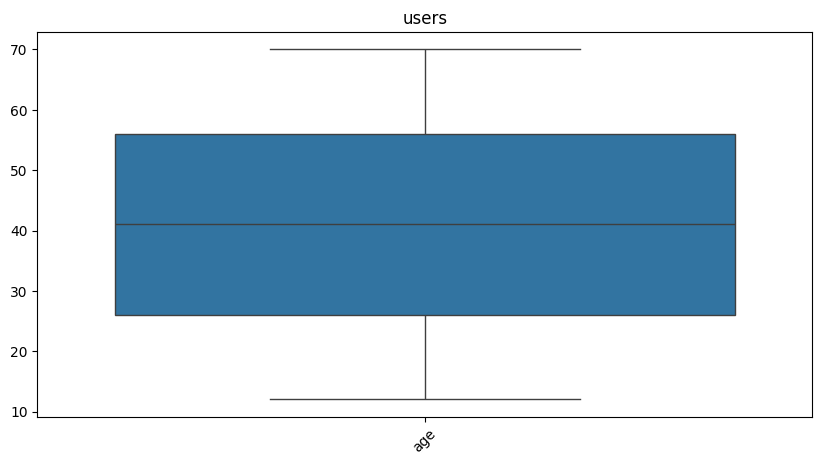

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

for name, df in data.items():
    numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
    
    if len(numeric_cols) == 0:
        continue
        
    plt.figure(figsize=(10, 5))
    # Sử dụng Seaborn để vẽ
    sns.boxplot(data=df[numeric_cols])
    
    plt.title(f"{name}")
    plt.xticks(rotation=45)
    plt.show()


In [71]:
import os

output_path = r"D:\the_look_portfilio\clean_data\clean_data"
os.makedirs(output_path, exist_ok=True)

for table_name, df in data.items():
    file_path = f"{output_path}/{table_name}.csv"
    df.to_csv(file_path, index=False)

print("All tables saved")

All tables saved
